# ARC free-parameter scan: separatrix-density heat maps

At a fixed `alpha_crit`, `C_KBM` and `De_chie_etg` (by default the
`ARC_workflow_noKBM_ETG05` scan from `scan_SCfp_ESCAPE.py`), these heat maps
show how the solved profiles at $\psi_N = 0.85$ depend on the two neutral-density
free parameters:

- horizontal axis: $n_{FC}(x=0)$
- vertical axis: $n_{CX}(x=0)/n_{FC}(x=0)$
- colour: $n_e$, $T_e$ and $p_e = n_e T_e$ at $\psi_N = 0.85$, one plot each

The $x=0$ values are read from the solved `nFC` / `nCX` profiles in
`profiles_solved`, and checked against the `nFC_x0` / `ncx_x0_ratio` free
parameters. The scan grid is unevenly spaced, so each grid value gets one
equal-size cell. Grey cells have not been solved yet (the scan may still be
running, so re-run the notebook to pick up new points). Runs that wrote
`failed.npy` are labelled *failed*.

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path

SCAN_DIR = Path('ARC_workflow_noKBM_ETG05_psi085')

# Slice held fixed while nFC(0) and nCX(0)/nFC(0) vary. None auto-picks the
# (alpha_crit, C_KBM, De_chie_etg) combination with the most solved runs.
FIXED = {'alpha_crit': None, 'C_KBM': None, 'De_chie_etg': None}

# Radial location at which the colour quantities are evaluated
PSI_EVAL = 0.85

# Scan grid from scan_SCfp_ESCAPE.py, so cells that have not run yet still show
# up as empty. Any extra values found on disk are added automatically.
NFC_X0_GRID = np.logspace(14.5, 17.0, 5)
NCX_RATIO_GRID = np.array([0.1, 1, 10, 20, 30])

e_C = 1.602176634e-19  # J/eV

In [26]:
def par(d, k):
    return float(d['free_params'][k])

def _dir_key(p):
    return int(p.parent.name.removeprefix('fp'))

def x0_densities(d):
    """nFC(x=0) and nCX(x=0)/nFC(x=0) from the solved neutral profiles."""
    s = d['profiles_solved']
    x = np.asarray(s['x'], float)
    i0 = np.argmin(np.abs(x))           # x = 0 is the separatrix end of the grid
    nFC0 = float(np.asarray(s['nFC'], float)[i0])
    nCX0 = float(np.asarray(s['nCX'], float)[i0])
    return nFC0, nCX0 / nFC0

def values_at_psi(d, psi):
    """ne [10^20 m^-3], Te [keV], p_e = ne*Te [kPa] at psi_N = psi.

    profiles_solved: 'y' is n_e [m^-3] on the (unsorted) 'psi_N_ne' grid,
    'T_e' is in eV on 'psi_N'.
    """
    s = d['profiles_solved']
    psi_ne = np.asarray(s['psi_N_ne'], float)
    o = np.argsort(psi_ne)
    ne = float(np.interp(psi, psi_ne[o], np.asarray(s['y'], float)[o]))
    psi_Te = np.asarray(s['psi_N'], float)
    o = np.argsort(psi_Te)
    Te = float(np.interp(psi, psi_Te[o], np.asarray(s['T_e'], float)[o]))
    return {'ne': ne / 1e20, 'Te': Te / 1e3, 'p': ne * Te * e_C / 1e3}

runs, failed = [], []
for fp in sorted(SCAN_DIR.glob('fp*/out_dict.npy'), key=_dir_key):
    d = np.load(fp, allow_pickle=True).item()
    if d.get('failed'):
        failed.append(d)
        continue
    runs.append(d)
for fp in sorted(SCAN_DIR.glob('fp*/failed.npy'), key=_dir_key):
    failed.append(np.load(fp, allow_pickle=True).item())

if not runs:
    raise RuntimeError(f'No completed runs with out_dict.npy found under {SCAN_DIR}')

# Resolve unset fixed values to the slice with the most solved runs
if any(v is None for v in FIXED.values()):
    from collections import Counter
    best = Counter(tuple(par(r, k) for k in FIXED) for r in runs).most_common(1)[0][0]
    FIXED = {k: (v if v is not None else b) for (k, v), b in zip(FIXED.items(), best)}

def in_slice(d):
    return all(np.isclose(par(d, k), v) for k, v in FIXED.items())

slice_runs = [r for r in runs if in_slice(r)]
slice_failed = [f for f in failed if in_slice(f)]

print('Holding fixed: ' + ',  '.join(f'{k} = {v:.4g}' for k, v in FIXED.items()))
print(f'{len(slice_runs)} solved, {len(slice_failed)} failed in this slice '
      f'({len(NFC_X0_GRID) * len(NCX_RATIO_GRID)} in the scan grid)')

# Sanity check: the x = 0 values of the solved neutral profiles are the free parameters
for r in slice_runs:
    nFC0, ratio0 = x0_densities(r)
    assert np.isclose(nFC0, par(r, 'nFC_x0')) and np.isclose(ratio0, par(r, 'ncx_x0_ratio')), \
        (nFC0, ratio0, r['free_params'])

Holding fixed: alpha_crit = 0.1,  C_KBM = 0,  De_chie_etg = 0.5
19 solved, 6 failed in this slice (25 in the scan grid)


In [27]:
# Fill the (ncx_ratio, nFC) grids. NaN = not solved; failed runs are marked separately.
def _merge(grid, extra):
    vals = list(grid)
    for v in extra:
        if not np.any(np.isclose(vals, v)):
            vals.append(v)
    return np.sort(np.asarray(vals, float))

nFC_vals = _merge(NFC_X0_GRID, [x0_densities(r)[0] for r in slice_runs]
                               + [par(f, 'nFC_x0') for f in slice_failed])
ratio_vals = _merge(NCX_RATIO_GRID, [x0_densities(r)[1] for r in slice_runs]
                                    + [par(f, 'ncx_x0_ratio') for f in slice_failed])

def _idx(vals, v):
    return int(np.argmin(np.abs(np.log(vals) - np.log(v))))

QUANTS = {
    'ne': {'label': rf'$n_e(\psi_N={PSI_EVAL})$ [$10^{{20}}$ m$^{{-3}}$]', 'cmap': 'Blues', 'fmt': '{:.3f}'},
    'Te': {'label': rf'$T_e(\psi_N={PSI_EVAL})$ [keV]',                  'cmap': 'Oranges', 'fmt': '{:.2f}'},
    'p':  {'label': rf'$p_e = n_e T_e\,(\psi_N={PSI_EVAL})$ [kPa]',        'cmap': 'Greens', 'fmt': '{:.1f}'},
}

grids = {k: np.full((len(ratio_vals), len(nFC_vals)), np.nan) for k in QUANTS}
failed_mask = np.zeros((len(ratio_vals), len(nFC_vals)), bool)

for r in slice_runs:
    nFC0, ratio0 = x0_densities(r)
    i, j = _idx(ratio_vals, ratio0), _idx(nFC_vals, nFC0)
    for k, v in values_at_psi(r, PSI_EVAL).items():
        grids[k][i, j] = v
for f in slice_failed:
    failed_mask[_idx(ratio_vals, par(f, 'ncx_x0_ratio')), _idx(nFC_vals, par(f, 'nFC_x0'))] = True

In [28]:
from matplotlib.colors import Normalize

def plot_heatmap(key):
    q = QUANTS[key]
    Z = grids[key]
    cmap = plt.get_cmap(q['cmap']).copy()
    cmap.set_bad('0.92')                 # unsolved / pending cells

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    finite = Z[np.isfinite(Z)]
    norm = Normalize(finite.min(), finite.max()) if finite.size else Normalize(0, 1)

    # Scan values are unevenly spaced, so draw one equal-size cell per grid value
    # and label the ticks with the actual values.
    im = ax.imshow(np.ma.masked_invalid(Z), origin='lower', aspect='auto',
                   cmap=cmap, norm=norm, interpolation='nearest')

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            if np.isfinite(Z[i, j]):
                shade = norm(Z[i, j])
                ax.text(j, i, q['fmt'].format(Z[i, j]), ha='center', va='center',
                        fontsize=10, color='white' if shade > 0.6 else 'black')
            elif failed_mask[i, j]:
                ax.text(j, i, 'failed', ha='center', va='center', fontsize=9, color='0.35')

    # Thin surface-coloured gaps between cells
    ax.set_xticks(np.arange(-0.5, Z.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, Z.shape[0]), minor=True)
    ax.grid(which='minor', color='white', lw=2)
    ax.tick_params(which='minor', length=0)

    ax.set_xticks(np.arange(len(nFC_vals)))
    ax.set_xticklabels([f'{v:.2e}' for v in nFC_vals], rotation=30, ha='right')
    ax.set_yticks(np.arange(len(ratio_vals)))
    ax.set_yticklabels([f'{v:g}' for v in ratio_vals])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel(r'$n_{FC}(x=0)$ [m$^{-3}$]', fontsize=14)
    ax.set_ylabel(r'$n_{CX}(x=0)\,/\,n_{FC}(x=0)$', fontsize=14)
    ax.set_title(rf'$\alpha_{{crit}}$ = {FIXED["alpha_crit"]:.3g},  '
                 rf'$C_{{KBM}}$ = {FIXED["C_KBM"]:.3g},  '
                 rf'$D_{{ETG}}/\chi_{{e}}$ = {FIXED["De_chie_etg"]:.3g}', fontsize=12)
    for s in ax.spines.values():
        s.set_visible(False)

    cb = fig.colorbar(im, ax=ax)
    cb.set_label(q['label'], fontsize=13)
    cb.ax.tick_params(labelsize=11)
    fig.tight_layout()
    return fig, ax

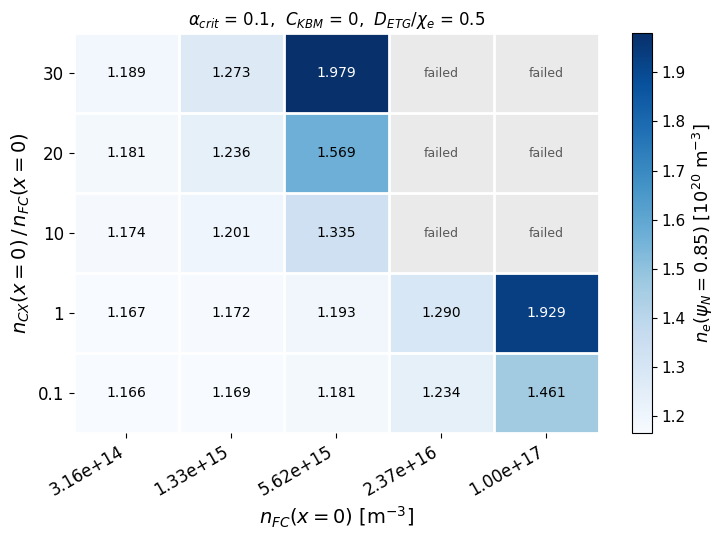

In [29]:
fig, ax = plot_heatmap('ne')
plt.show()

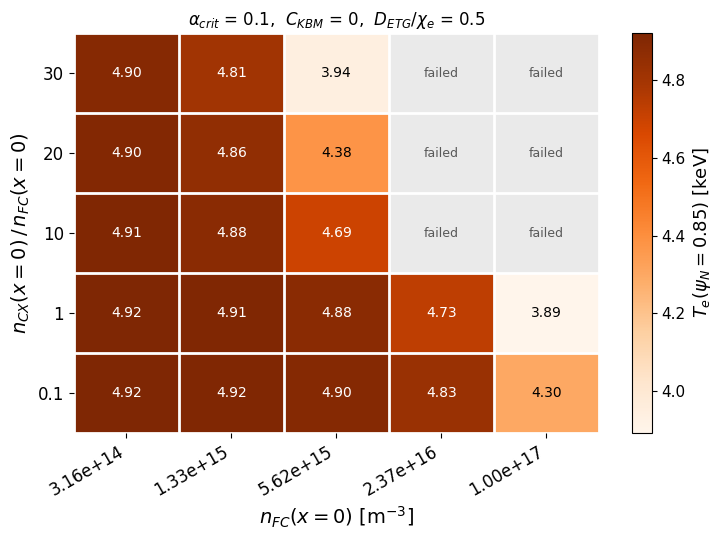

In [30]:
fig, ax = plot_heatmap('Te')
plt.show()

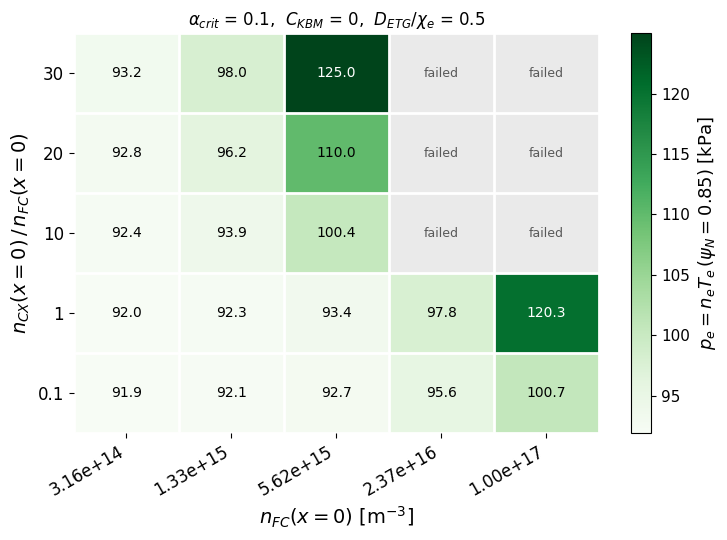

In [31]:
fig, ax = plot_heatmap('p')
plt.show()

## Profiles at $\psi_N = 0.85$ versus separatrix density

The same slice collapsed onto one axis,

$$n_{sep} = n_{FC}(x=0) + \left(\frac{n_{CX}}{n_{FC}}\,n_{FC}\right)(x=0) = n_{FC}(x=0) + n_{CX}(x=0)$$

with $n_e$ and $T_e$ on separate y-axes. $p_e$ is in arbitrary units, rescaled
onto the $n_e$ axis (mean matched to the mean of $n_e$) so its trend can be
compared directly. The runs are joined in order of $n_{sep}$, so combinations with
nearly equal $n_{sep}$ but different $n_{CX}/n_{FC}$ show up as steps.

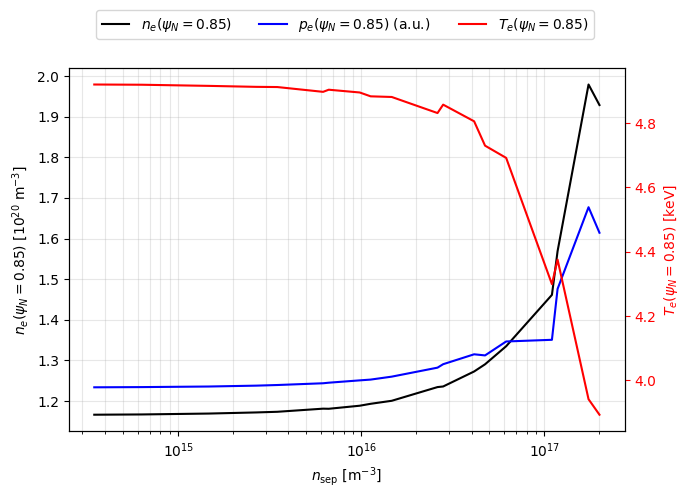

19 runs, values at psi_N = 0.85


In [32]:
def n_sep_x0(r):
    # n_sep = nFC(x=0) + (nCX/nFC * nFC)(x=0)
    nFC0, ratio0 = x0_densities(r)
    return nFC0 + ratio0 * nFC0

sep_runs = sorted(slice_runs, key=n_sep_x0)
nsep = np.array([n_sep_x0(r) for r in sep_runs])
at = [values_at_psi(r, PSI_EVAL) for r in sep_runs]
ne_sep = np.array([v['ne'] for v in at])
Te_sep = np.array([v['Te'] for v in at])
pe_sep = np.array([v['p'] for v in at])

# p_e in arbitrary units, placed on the n_e axis
pe_au = pe_sep * ne_sep.mean() / pe_sep.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax2 = ax.twinx()

ax.plot(nsep, ne_sep, '-', color='k', label=rf'$n_e(\psi_N={PSI_EVAL})$')
ax.plot(nsep, pe_au, '-', color='b', label=rf'$p_e(\psi_N={PSI_EVAL})$ (a.u.)')
ax2.plot(nsep, Te_sep, '-', color='r', label=rf'$T_e(\psi_N={PSI_EVAL})$')

ax.set_xscale('log')
ax.set_xlabel(r'$n_{\rm sep}$ [m$^{-3}$]')
ax.set_ylabel(rf'$n_e(\psi_N={PSI_EVAL})$ [$10^{{20}}$ m$^{{-3}}$]')
ax2.set_ylabel(rf'$T_e(\psi_N={PSI_EVAL})$ [keV]', color='r')
ax2.tick_params(axis='y', colors='r')
ax.grid(alpha=0.3, which='both')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

print(f'{len(sep_runs)} runs, values at psi_N = {PSI_EVAL}')

## ESCAPE loop convergence tolerance, one line per $n_{sep}$

`loop_tol` is the normalized change in pedestal height + width between an ESCAPE
iteration and the previous one; the loop stops once $|{\rm loop\ tol}|$ <
`eped_tol_max`. It is read from the per-iteration dumps
`fp<i>/<equilibrium>/ne_and_Te_iter_<k>.npy`, so runs that are still going (no
`out_dict.npy` yet) or that failed are included and marked in the legend.
$n_{sep} = n_{FC}(x=0) + (n_{CX}/n_{FC}\cdot n_{FC})(x=0)$ comes from the same
dumps. Lines are coloured by $n_{sep}$ on a log scale.

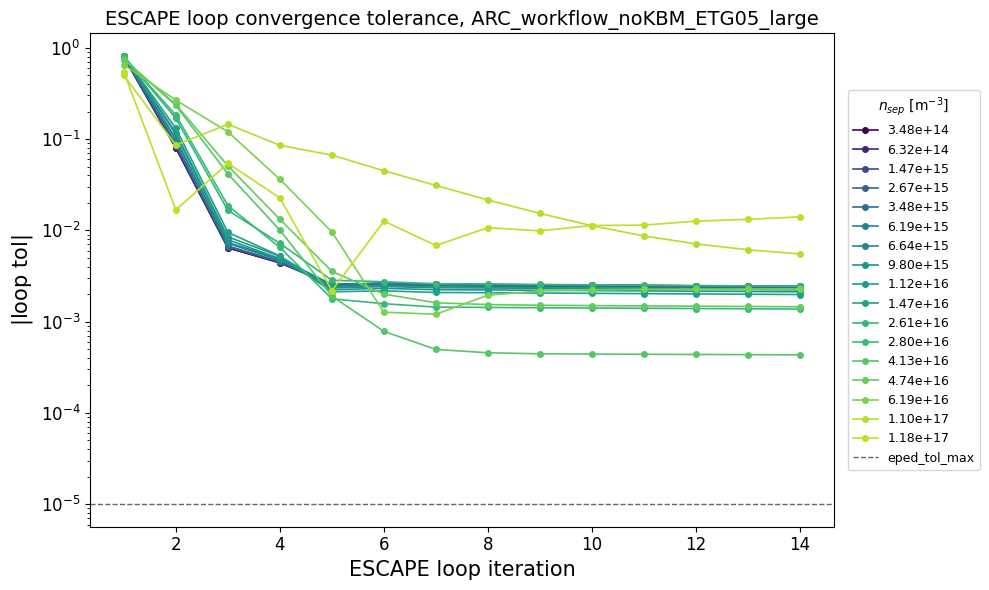

  fp0  n_sep = 3.479e+14  (nFC_x0 = 3.16e+14, ratio = 0.1)  14 iterations, final |tol| = 2.43e-03, done
  fp1  n_sep = 6.325e+14  (nFC_x0 = 3.16e+14, ratio = 1)  14 iterations, final |tol| = 2.42e-03, done
  fp5  n_sep = 1.467e+15  (nFC_x0 = 1.33e+15, ratio = 0.1)  14 iterations, final |tol| = 2.43e-03, done
  fp6  n_sep = 2.667e+15  (nFC_x0 = 1.33e+15, ratio = 1)  14 iterations, final |tol| = 2.39e-03, done
  fp2  n_sep = 3.479e+15  (nFC_x0 = 3.16e+14, ratio = 10)  14 iterations, final |tol| = 2.33e-03, done
 fp10  n_sep = 6.186e+15  (nFC_x0 = 5.62e+15, ratio = 0.1)  14 iterations, final |tol| = 2.42e-03, done
  fp3  n_sep = 6.641e+15  (nFC_x0 = 3.16e+14, ratio = 20)  14 iterations, final |tol| = 2.23e-03, done
  fp4  n_sep = 9.803e+15  (nFC_x0 = 3.16e+14, ratio = 30)  14 iterations, final |tol| = 2.12e-03, done
 fp11  n_sep = 1.125e+16  (nFC_x0 = 5.62e+15, ratio = 1)  14 iterations, final |tol| = 2.26e-03, done
  fp7  n_sep = 1.467e+16  (nFC_x0 = 1.33e+15, ratio = 10)  14 iterations,

In [18]:
ITER_SCAN_DIR = Path('ARC_workflow_noKBM_ETG05_large')
EPED_TOL_MAX = 1e-5     # eped_tol_max in scan_SCfp_ESCAPE.py, drawn for reference
TOL_CMAP = 'viridis'

def load_iter_dumps(fp_dir):
    # All ne_and_Te_iter_<k>.npy dumps of one scan point, in iteration order
    files = sorted(fp_dir.glob('*/ne_and_Te_iter_*.npy'),
                   key=lambda f: int(f.stem.rsplit('_', 1)[-1]))
    return [(int(f.stem.rsplit('_', 1)[-1]), np.load(f, allow_pickle=True).item()) for f in files]

def n_sep_dump(s):
    # n_sep = nFC(x=0) + (nCX/nFC * nFC)(x=0), from a profiles dict with x, nFC, nCX
    x = np.asarray(s['x'], float)
    i0 = np.argmin(np.abs(x))
    nFC0 = float(np.asarray(s['nFC'], float)[i0])
    ratio0 = float(np.asarray(s['nCX'], float)[i0]) / nFC0
    return nFC0 + ratio0 * nFC0

tol_runs = []
for fp_dir in sorted(ITER_SCAN_DIR.glob('fp*'), key=lambda p: int(p.name.removeprefix('fp'))):
    dumps = load_iter_dumps(fp_dir)
    tols = [(k, float(s['loop_tol'])) for k, s in dumps if 'loop_tol' in s]
    if not tols:
        continue
    status = ('done' if (fp_dir / 'out_dict.npy').exists()
              else 'failed' if (fp_dir / 'failed.npy').exists() else 'in progress')
    s0 = dumps[0][1]
    tol_runs.append({'fp': fp_dir.name, 'n_sep': n_sep_dump(s0), 'nFC_x0': float(s0['nFC_x0']),
                     'ncx_x0_ratio': float(s0['ncx_x0_ratio']), 'tols': tols, 'status': status})

if not tol_runs:
    raise RuntimeError(f'No iteration dumps with loop_tol found under {ITER_SCAN_DIR}')
tol_runs.sort(key=lambda r: r['n_sep'])

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap(TOL_CMAP)
nsep_all = np.array([r['n_sep'] for r in tol_runs])
lo, hi = np.log10(nsep_all.min()), np.log10(nsep_all.max())

for r in tol_runs:
    it, tol = zip(*r['tols'])
    c = cmap(0.9 * (np.log10(r['n_sep']) - lo) / (hi - lo)) if hi > lo else 'C0'
    tag = '' if r['status'] == 'done' else f"  ({r['status']})"
    ax.plot(it, np.abs(tol), 'o-', markersize=4, linewidth=1.2, color=c,
            label=rf"{r['n_sep']:.2e}{tag}")

ax.axhline(EPED_TOL_MAX, color='0.4', ls='--', lw=1, label='eped_tol_max')
ax.set_yscale('log')
ax.set_xlabel('ESCAPE loop iteration', fontsize=15)
ax.set_ylabel(r'$|{\rm loop\ tol}|$', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'ESCAPE loop convergence tolerance, {ITER_SCAN_DIR}', fontsize=14)
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.01, 0.5),
          title=r'$n_{sep}$ [m$^{-3}$]', title_fontsize=10,
          ncol=1 if len(tol_runs) <= 20 else 2)
plt.tight_layout()
plt.show()

for r in tol_runs:
    print(f"{r['fp']:>5}  n_sep = {r['n_sep']:.3e}  (nFC_x0 = {r['nFC_x0']:.2e}, "
          f"ratio = {r['ncx_x0_ratio']:g})  {len(r['tols'])} iterations, "
          f"final |tol| = {abs(r['tols'][-1][1]):.2e}, {r['status']}")

## $n_e$ and $T_e$ profiles through the ESCAPE iterations

Four $n_{sep}$ values, evenly spaced through the sorted list of completed runs
(those with `out_dict.npy`) from `ITER_SCAN_DIR`. Each row is one $n_{sep}$: $n_e$
on the left and $T_e$ on the right, one line per ESCAPE iteration, coloured from
the first iteration (light) to the last (dark). The digitized ARC input profile is
dotted black. $n_e$ ('y', m$^{-3}$) is on the solved pedestal grid 'psi_N_ne'
(unsorted in the dump); $T_e$ ('T_e', eV) is on 'psi_N'.

17 completed runs; plotting n_sep = 3.48e+14 (fp0), 6.19e+15 (fp10), 2.80e+16 (fp8), 1.18e+17 (fp13)


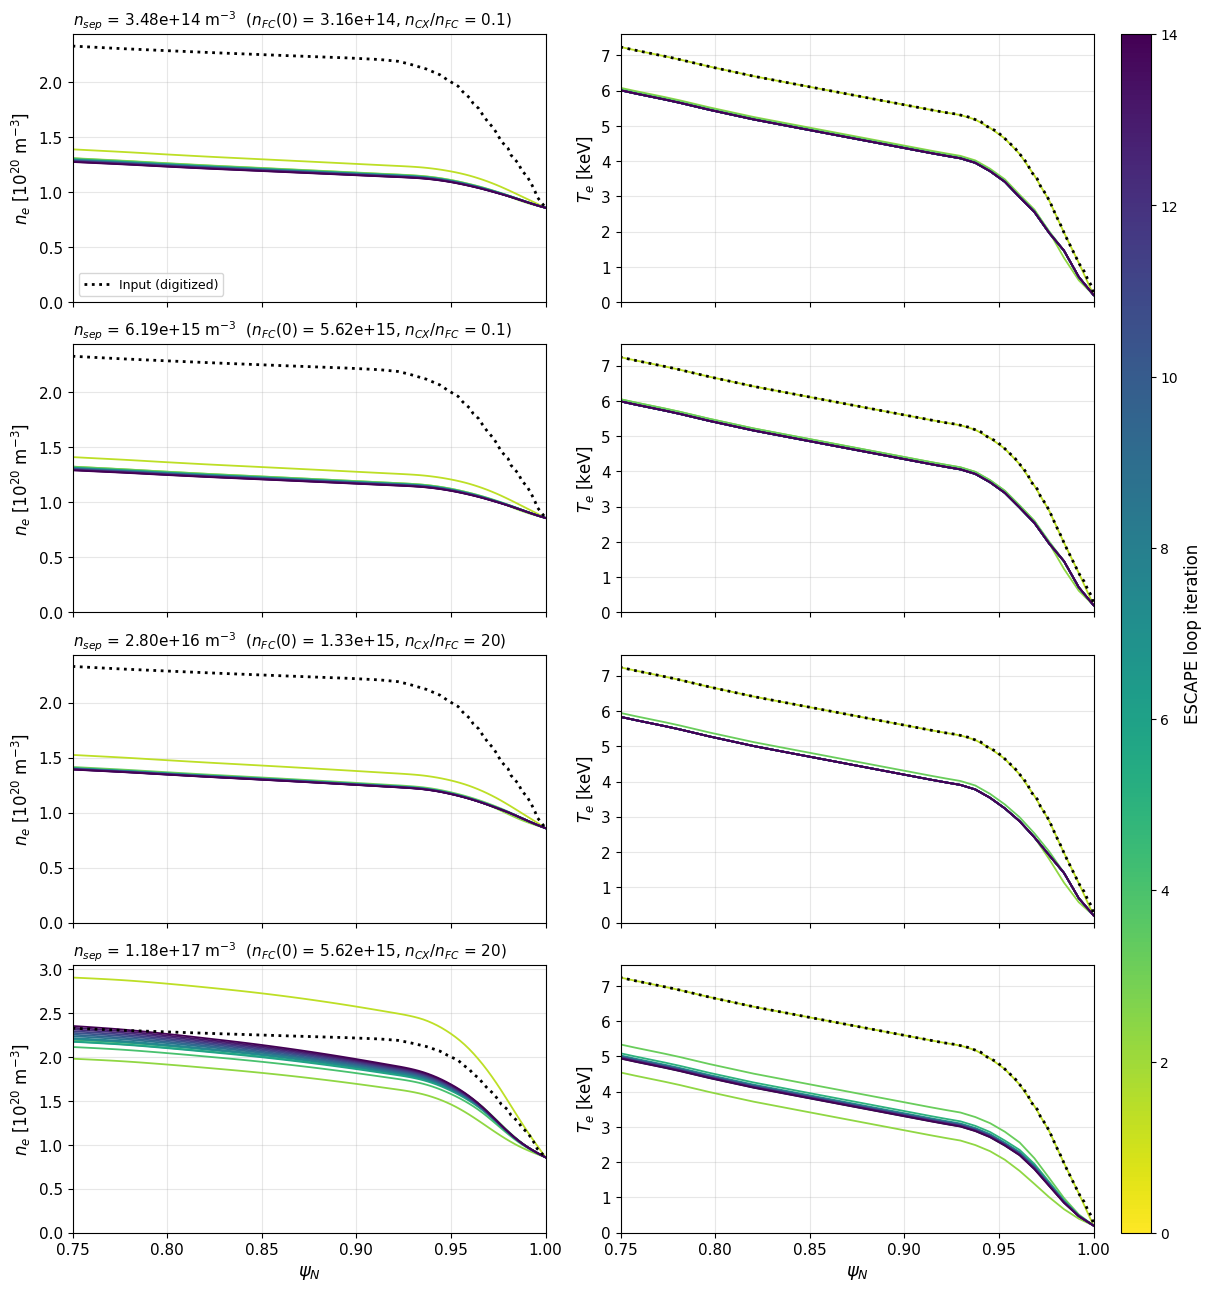

In [19]:
from matplotlib.cm import ScalarMappable

def zoom_y(ax, x_lo, x_hi=1.0, pad=0.05):
    # Autoscale y over only the data inside [x_lo, x_hi]; the input profiles run
    # to the axis, where they are far above the pedestal
    top = 0.0
    for ln in ax.get_lines():
        x = np.asarray(ln.get_xdata(), float)
        y = np.asarray(ln.get_ydata(), float)
        m = (x >= x_lo) & (x <= x_hi) & np.isfinite(y)
        if m.any():
            top = max(top, float(np.max(y[m])))
    if top > 0:
        ax.set_ylim(0, top * (1 + pad))

N_PROFILE_ROWS = 4
PROF_CMAP = 'viridis_r'   # light = early iteration, dark = late

done_runs = [r for r in tol_runs if r['status'] == 'done']   # tol_runs is sorted by n_sep
if not done_runs:
    raise RuntimeError(f'No completed runs under {ITER_SCAN_DIR} yet')
pick = np.unique(np.round(np.linspace(0, len(done_runs) - 1,
                                      min(N_PROFILE_ROWS, len(done_runs)))).astype(int))
prof_runs = [done_runs[i] for i in pick]
print(f'{len(done_runs)} completed runs; plotting n_sep = '
      + ', '.join(f"{r['n_sep']:.2e} ({r['fp']})" for r in prof_runs))

fig, axes = plt.subplots(len(prof_runs), 2, figsize=(12, 3.2 * len(prof_runs)),
                         squeeze=False, sharex=True, layout='constrained')
cmap = plt.get_cmap(PROF_CMAP)

# One iteration colour scale shared by every row
iter_dumps = {r['fp']: load_iter_dumps(ITER_SCAN_DIR / r['fp']) for r in prof_runs}
norm = Normalize(0, max(1, max(k for d in iter_dumps.values() for k, _ in d)))

for row, r in zip(axes, prof_runs):
    fp_dir = ITER_SCAN_DIR / r['fp']
    dumps = iter_dumps[r['fp']]
    ref = np.load(fp_dir / 'out_dict.npy', allow_pickle=True).item()['profiles']

    psi_lo = 1.0
    for k, s in dumps:
        c = cmap(0.1 + 0.9 * norm(k))
        psi_ne = np.asarray(s['psi_N_ne'], float)
        o = np.argsort(psi_ne)
        row[0].plot(psi_ne[o], np.asarray(s['y'], float)[o] / 1e20, '-', lw=1.3, color=c)
        row[1].plot(np.asarray(s['psi_N'], float), np.asarray(s['T_e'], float) / 1e3,
                    '-', lw=1.3, color=c)
        psi_lo = min(psi_lo, float(psi_ne.min()))

    row[0].plot(ref['psi_N_ne'], np.asarray(ref['ne'], float) / 1e20, 'k:', lw=2, label='Input (digitized)')
    row[1].plot(ref['psi_N_Te'], ref['Te'], 'k:', lw=2, label='Input (digitized)')

    for ax in row:
        ax.set_xlim(psi_lo, 1.0)
        zoom_y(ax, psi_lo)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='both', labelsize=11)
    row[0].set_ylabel(r'$n_e$ [$10^{20}$ m$^{-3}$]', fontsize=12)
    row[1].set_ylabel(r'$T_e$ [keV]', fontsize=12)
    row[0].set_title(rf"$n_{{sep}}$ = {r['n_sep']:.2e} m$^{{-3}}$  "
                     rf"($n_{{FC}}(0)$ = {r['nFC_x0']:.2e}, $n_{{CX}}/n_{{FC}}$ = {r['ncx_x0_ratio']:g})",
                     fontsize=11, loc='left')

sm = ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=axes, pad=0.01, aspect=40).set_label('ESCAPE loop iteration', fontsize=12)
axes[0, 0].legend(fontsize=9, loc='lower left')
for ax in axes[-1]:
    ax.set_xlabel(r'$\psi_N$', fontsize=13)
plt.show()